# Neural MPLE with similarity-weighted neighbor averages for DGL Fraud Yelp

This notebook combines the previous similarity-weighted graph signal with a neural external field.

The main fitted model is

$$
\mathbb P_{\beta,\theta}(\sigma_i=1\mid \sigma_{-i},X,G)
=
\operatorname{logit}^{-1}(2h_i),
$$

where

$$
h_i
=
\sum_{r=1}^3 \beta_r \overline S^{\,w}_{ir}
+
2b_\theta(X_i).
$$

Here

$$
\overline S^{\,w}_{ir}
=
\frac{
\sum_{j:(j,i)\in E_r}w^{(r)}_{ij}\sigma_j^{\mathrm{obs}}
}{
\sum_{j:(j,i)\in E_r}w^{(r)}_{ij}\mathbf 1\{j\text{ observed}\}+\varepsilon
}.
$$

The default similarity weight is feature-RBF similarity,

$$
w^{(r)}_{ij}
=
\exp\left(
-\frac{\|X_i-X_j\|_2^2}{2\tau_r^2}
\right),
$$

with $\tau_r$ estimated separately for each relation by the median edgewise feature distance.

This keeps the graph term interpretable through $\beta_1,\beta_2,\beta_3$, while replacing the linear external field $X_i^\top\gamma$ by a neural network $b_\theta(X_i)$.

The notebook also includes an optional fully neural local-field model

$$
h_i=f_\theta(X_i,\overline S^w_{i1},\overline S^w_{i2},\overline S^w_{i3}),
$$

but that version no longer preserves interpretable $\beta_r$'s.


In [1]:
# If needed, install dependencies first. Pick the DGL wheel matching your PyTorch version.
# %pip install -q scikit-learn pandas matplotlib
# %pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html


In [2]:
import math
import random
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt

import dgl
from dgl.data import FraudYelpDataset


SEED = 717

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load Fraud Yelp

The original labels are $y_i\in\{0,1\}$. We convert them to spins by

$$
\sigma_i=2y_i-1.
$$


In [3]:
dataset = FraudYelpDataset(
    random_seed=SEED,
    train_size=0.7,
    val_size=0.1,
    verbose=True,
)

g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [4]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when the graph has multiple node types.")
        ntype = g.ntypes[0]

    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value


ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()

train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [
        int(train_mask.sum()),
        int(val_mask.sum()),
        int(test_mask.sum()),
        int(y01.numel()),
    ],
    "positives_label_1": [
        int(y01[train_mask].sum()),
        int(y01[val_mask].sum()),
        int(y01[test_mask].sum()),
        int(y01.sum()),
    ],
})
summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [5]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]

BETA_LABELS = [
    "beta_1: net_rur",
    "beta_2: net_rsr",
    "beta_3: net_rtr",
]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


## Standardize node features

The neural network receives standardized features. The mean and standard deviation are computed from training nodes only.


In [6]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    X_std = (X - mean) / std
    return X_std, mean, std


X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)

print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Similarity-weighted neighbor averages

By default, only training labels are treated as observed:

$$
\sigma_j^{\mathrm{obs}}
=
\begin{cases}
\sigma_j, & j\in\mathcal T,\\
0, & j\notin\mathcal T.
\end{cases}
$$

This avoids using validation/test labels inside the graph covariates.


In [7]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic only

SIMILARITY_MODE = "cosine_positive"  # one of {"rbf_features", "cosine_positive"}

# Chunk size controls memory use. Reduce this if you run out of memory.
EDGE_CHUNK_SIZE = 500_000

# Number of edges sampled per relation to estimate the RBF scale tau_r.
TAU_SAMPLE_SIZE = 200_000

# If True, denominator averages only over observed-label source nodes.
DENOMINATOR_USES_ONLY_OBSERVED_LABELS = True


@torch.no_grad()
def estimate_relation_taus_from_edge_samples(
    g,
    X_for_similarity,
    edge_types,
    sample_size=200_000,
    seed=717,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    rng = np.random.default_rng(seed)
    X_dev = X_for_similarity.to(device).float()

    tau_values = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        m = src.numel()

        if m == 0:
            tau_values.append(1.0)
            continue

        k = min(sample_size, m)
        sample_idx = rng.choice(m, size=k, replace=False)

        src_s = src[sample_idx].to(device)
        dst_s = dst[sample_idx].to(device)

        diff = X_dev[src_s] - X_dev[dst_s]
        dist = diff.pow(2).sum(dim=1).sqrt()

        tau = torch.median(dist).item()
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = float(dist.mean().item())
        if not np.isfinite(tau) or tau <= 1e-12:
            tau = 1.0

        tau_values.append(float(tau))

    return torch.tensor(tau_values, dtype=torch.float32)


@torch.no_grad()
def edge_similarity_weights(X_dev, src, dst, mode, tau=None):
    if mode == "rbf_features":
        if tau is None:
            raise ValueError("tau is required for rbf_features similarity.")
        diff = X_dev[src] - X_dev[dst]
        dist2 = diff.pow(2).sum(dim=1)
        w = torch.exp(-dist2 / (2.0 * float(tau) ** 2))
        return w

    if mode == "cosine_positive":
        x_src = X_dev[src]
        x_dst = X_dev[dst]
        numerator = (x_src * x_dst).sum(dim=1)
        denom = x_src.norm(dim=1).clamp_min(1e-12) * x_dst.norm(dim=1).clamp_min(1e-12)
        cosine = numerator / denom
        return torch.clamp(cosine, min=0.0, max=1.0)

    raise ValueError("SIMILARITY_MODE must be one of {'rbf_features', 'cosine_positive'}.")


@torch.no_grad()
def compute_similarity_weighted_neighbor_averages(
    g,
    sigma_all,
    observed_mask,
    X_for_similarity,
    edge_types,
    similarity_mode="rbf_features",
    tau_values=None,
    denominator_observed_only=True,
    chunk_size=500_000,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n = sigma_all.numel()

    X_dev = X_for_similarity.to(device).float()
    sigma_dev = sigma_all.to(device).float()
    obs_dev = observed_mask.to(device).bool()

    avg_columns = []
    numerator_columns = []
    denominator_columns = []

    for r, etype in enumerate(edge_types):
        src_cpu, dst_cpu = g.edges(etype=etype)
        m = src_cpu.numel()

        numerator = torch.zeros(n, dtype=torch.float32, device=device)
        denominator = torch.zeros(n, dtype=torch.float32, device=device)

        tau_r = None
        if similarity_mode == "rbf_features":
            tau_r = float(tau_values[r])

        for start in range(0, m, chunk_size):
            end = min(start + chunk_size, m)

            src = src_cpu[start:end].to(device)
            dst = dst_cpu[start:end].to(device)

            w = edge_similarity_weights(
                X_dev,
                src,
                dst,
                mode=similarity_mode,
                tau=tau_r,
            )

            obs_src = obs_dev[src].float()

            weighted_spin = w * obs_src * sigma_dev[src]
            numerator.index_add_(0, dst, weighted_spin)

            if denominator_observed_only:
                denominator_increment = w * obs_src
            else:
                denominator_increment = w

            denominator.index_add_(0, dst, denominator_increment)

        avg = numerator / denominator.clamp_min(1e-12)
        avg = torch.where(denominator > 0, avg, torch.zeros_like(avg))

        avg_columns.append(avg.cpu())
        numerator_columns.append(numerator.cpu())
        denominator_columns.append(denominator.cpu())

    Sbar_w = torch.stack(avg_columns, dim=1)
    N_w = torch.stack(numerator_columns, dim=1)
    D_w = torch.stack(denominator_columns, dim=1)

    return Sbar_w, N_w, D_w


## Estimate relation-specific RBF bandwidths


In [8]:
tau_values = estimate_relation_taus_from_edge_samples(
    g=g,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    sample_size=TAU_SAMPLE_SIZE,
    seed=SEED,
    device=device,
)

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "tau_r": tau_values.numpy(),
})


,edge_type,tau_r
0,net_rur,6.746763
1,net_rsr,7.590441
2,net_rtr,7.569873


## Build $\overline S^{\,w}$


In [9]:
Sbar_w, numerator_w, denominator_w = compute_similarity_weighted_neighbor_averages(
    g=g,
    sigma_all=sigma_all,
    observed_mask=SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES,
    X_for_similarity=X,
    edge_types=EDGE_TYPES,
    similarity_mode=SIMILARITY_MODE,
    tau_values=tau_values,
    denominator_observed_only=DENOMINATOR_USES_ONLY_OBSERVED_LABELS,
    chunk_size=EDGE_CHUNK_SIZE,
    device=device,
)

pd.DataFrame(Sbar_w[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-0.373472,0.519389,-1.0,-1.000000,0.000000,0.000000,1.0
net_rsr,32167.0,-0.714389,0.294284,-1.0,-0.901667,-0.797873,-0.633094,1.0
net_rtr,32167.0,-0.690636,0.399517,-1.0,-1.000000,-0.843196,-0.528417,1.0


In [10]:
neighbor_summary = pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "mean_weighted_denominator_train": denominator_w[train_mask].mean(dim=0).numpy(),
    "median_weighted_denominator_train": denominator_w[train_mask].median(dim=0).values.numpy(),
    "fraction_train_with_no_observed_weighted_neighbors": (denominator_w[train_mask] <= 0).float().mean(dim=0).numpy(),
})

neighbor_summary


,edge_type,mean_weighted_denominator_train,median_weighted_denominator_train,fraction_train_with_no_observed_weighted_neighbors
0,net_rur,0.418040,0.000000,0.590108
1,net_rsr,13.915053,12.457726,0.002394
2,net_rtr,2.445546,1.973894,0.025150


## Model 1: similarity-weighted graph field + neural external field

The main model is

$$
h_i
=
\sum_{r=1}^3\beta_r\overline S^{\,w}_{ir}
+
2b_\theta(X_i).
$$

This is the direct analogue of the previous linear model, with $X_i^\top\gamma$ replaced by $b_\theta(X_i)$.

Set

```python
BETA_CONSTRAINT = "unconstrained"
```

to allow $\beta_r\in\mathbb R$, or

```python
BETA_CONSTRAINT = "nonnegative"
```

to enforce $\beta_r\ge 0$.


In [11]:
BETA_CONSTRAINT = "unconstrained"  # one of {"unconstrained", "nonnegative"}


def inverse_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return y + torch.log(-torch.expm1(-y))


class SimilarityWeightedNeuralExternalFieldMPLE(nn.Module):
    def __init__(
        self,
        n_features,
        n_relations=3,
        hidden=64,
        dropout=0.2,
        beta_constraint="unconstrained",
    ):
        super().__init__()

        if beta_constraint not in {"unconstrained", "nonnegative"}:
            raise ValueError("beta_constraint must be 'unconstrained' or 'nonnegative'.")

        self.beta_constraint = beta_constraint

        if beta_constraint == "unconstrained":
            self.beta_param = nn.Parameter(torch.zeros(n_relations))
        else:
            beta_init = torch.full((n_relations,), 1e-4)
            self.beta_param = nn.Parameter(inverse_softplus(beta_init))

        self.field_net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    @property
    def beta(self):
        if self.beta_constraint == "unconstrained":
            return self.beta_param
        return F.softplus(self.beta_param)

    def field(self, X):
        return self.field_net(X).squeeze(-1)

    def logits(self, Sbar_w, X):
        b = self.field(X)
        h = Sbar_w @ self.beta + 2.0 * b
        return 2.0 * h

    def forward(self, Sbar_w, X):
        return self.logits(Sbar_w, X)


## Metrics and utilities


In [12]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out


@torch.no_grad()
def predict_prob(model, Sbar_w, X, device):
    model.eval()
    logits = model(Sbar_w.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()


def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)

    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t = 0.5
    best_value = -np.inf

    for t in thresholds:
        pred = (score >= t).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'.")

        if value > best_value:
            best_value = value
            best_t = float(t)

    return best_t, best_value


def evaluate_splits(model, Sbar_w, X, y01, masks, threshold, device):
    prob = predict_prob(model, Sbar_w, X, device).numpy()
    y_np = y01.numpy().astype(int)

    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)

    return pd.DataFrame(rows)


## Train neural external-field model

The ordinary pseudo-likelihood uses `USE_POS_WEIGHT = False`.

If the target is minority-class F1 rather than parameter interpretation, try `USE_POS_WEIGHT = True`. This changes the objective into a weighted pseudo-likelihood classifier.


In [13]:
def train_similarity_weighted_neural_external_field_mple(
    Sbar_w,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    beta_constraint="unconstrained",
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = Sbar_w.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = SimilarityWeightedNeuralExternalFieldMPLE(
        n_features=X.shape[1],
        n_relations=Sbar_w.shape[1],
        hidden=hidden,
        dropout=dropout,
        beta_constraint=beta_constraint,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        beta = model.beta
        beta_penalty = 0.5 * l2_beta * (beta @ beta)

        loss = train_loss_data + beta_penalty
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "beta_1": float(model.beta.detach().cpu()[0]),
            "beta_2": float(model.beta.detach().cpu()[1]),
            "beta_3": float(model.beta.detach().cpu()[2]),
            "beta_norm": float(model.beta.detach().norm().cpu()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} "
                f"beta={model.beta.detach().cpu().numpy()}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
        "beta_constraint": beta_constraint,
    }

    return model, history_df, fit_info


In [14]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_similarity_weighted_neural_external_field_mple(
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden=64,
    dropout=0.2,
    beta_constraint=BETA_CONSTRAINT,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.65499 val_loss=0.65528 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.35046 val_loss=0.34804 beta=[0.04025543 0.02843731 0.02732798]
epoch= 100 train_loss=0.32054 val_loss=0.32142 beta=[0.07898577 0.05137782 0.04821408]
epoch= 150 train_loss=0.30035 val_loss=0.30596 beta=[0.11780788 0.0756541  0.0700822 ]
epoch= 200 train_loss=0.28567 val_loss=0.29471 beta=[0.15625812 0.10066054 0.09240226]
epoch= 250 train_loss=0.27490 val_loss=0.28542 beta=[0.19442691 0.12624823 0.11488706]
epoch= 300 train_loss=0.26550 val_loss=0.27673 beta=[0.23218141 0.15226802 0.13737863]
epoch= 350 train_loss=0.25714 val_loss=0.26902 beta=[0.26935208 0.17848419 0.15957582]
epoch= 400 train_loss=0.24905 val_loss=0.26249 beta=[0.30580592 0.20461702 0.18118104]
epoch= 450 train_loss=0.24117 val_loss=0.25611 beta=[0.34152782 0.23058107 0.20217994]
epoch= 500 train_loss=0.23334 val_loss=0.24941 beta=[0.37639603 0.256379   0.22250631]
epoch= 550 train_loss=0.22517 val_loss=0.24241 beta=[0.410

{'best_epoch': 999,
 'best_val_loss': 0.20234820246696472,
 'pos_weight': None,
 'beta_constraint': 'unconstrained'}

In [15]:
history_df.tail()


,epoch,train_loss,val_loss,beta_1,beta_2,beta_3,beta_norm
995,995,0.176246,0.202420,0.675369,0.484930,0.378523,0.913542
996,996,0.176192,0.202375,0.675909,0.485337,0.378750,0.914252
997,997,0.176143,0.202384,0.676448,0.485740,0.378975,0.914958
998,998,0.176116,0.202400,0.676987,0.486144,0.379201,0.915664
999,999,0.176086,0.202348,0.677526,0.486548,0.379425,0.916370


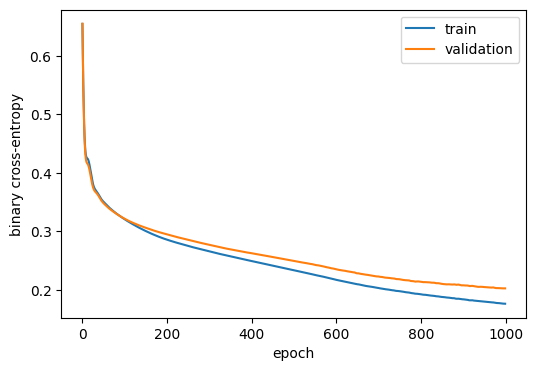

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


## Estimated $\beta$'s


In [17]:
with torch.no_grad():
    beta_hat = model.beta.detach().cpu()
    beta_param_hat = model.beta_param.detach().cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_beta": beta_hat.numpy(),
    "internal_beta_param": beta_param_hat.numpy(),
    "constraint": BETA_CONSTRAINT,
})

beta_df


,parameter,estimate_beta,internal_beta_param,constraint
0,beta_1: net_rur,0.677526,0.677526,unconstrained
1,beta_2: net_rsr,0.486548,0.486548,unconstrained
2,beta_3: net_rtr,0.379425,0.379425,unconstrained


## Learned neural external field $b_\theta(X_i)$


In [18]:
@torch.no_grad()
def compute_learned_field(model, X, device):
    model.eval()
    b = model.field(X.to(device).float())
    return b.detach().cpu()


b_hat = compute_learned_field(model, X, device)

field_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "mean_b_hat": [
        float(b_hat[train_mask].mean()),
        float(b_hat[val_mask].mean()),
        float(b_hat[test_mask].mean()),
        float(b_hat.mean()),
    ],
    "std_b_hat": [
        float(b_hat[train_mask].std(unbiased=False)),
        float(b_hat[val_mask].std(unbiased=False)),
        float(b_hat[test_mask].std(unbiased=False)),
        float(b_hat.std(unbiased=False)),
    ],
})

field_summary


,split,mean_b_hat,std_b_hat
0,train,-0.327233,0.445171
1,validation,-0.320154,0.434935
2,test,-0.327275,0.435410
3,all,-0.326533,0.442223


In [19]:
pd.DataFrame({
    "y": y01.numpy(),
    "sigma": sigma_all.numpy(),
    "b_hat": b_hat.numpy(),
    "train": train_mask.numpy(),
    "validation": val_mask.numpy(),
    "test": test_mask.numpy(),
}).groupby("y")["b_hat"].describe()


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,39277.0,-0.422976,0.378572,-2.510341,-0.642434,-0.394767,-0.170458,1.057767
1,6677.0,0.240782,0.355478,-1.158270,-0.000104,0.237604,0.482967,1.458243


## Prediction and evaluation


In [20]:
masks = {
    "train": train_mask,
    "validation": val_mask,
    "test": test_mask,
}

metrics_05 = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=0.5,
    device=device,
)

metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.932446,0.796988,0.903063,0.605163,0.724693,27134,307,1866,2860,0.961153,0.863997,train
1,0.5,4595,0.141676,0.921001,0.766729,0.834884,0.551459,0.664200,3873,71,292,359,0.937937,0.791520,validation
2,0.5,9192,0.141427,0.923520,0.768167,0.856631,0.551538,0.671034,7772,120,583,717,0.940625,0.794176,test


In [21]:
prob = predict_prob(model, Sbar_w, X, device).numpy()
y_np = y01.numpy().astype(int)

val_idx = val_mask.numpy().astype(bool)

best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="balanced_accuracy",
)

best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="f1",
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.14100000000000001 value: 0.862722508358182
Best validation threshold for F1: 0.339 value: 0.7168913560666138


In [22]:
metrics_val_balacc = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_balacc,
    device=device,
)

metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.141,32167,0.146921,0.877110,0.895131,0.548745,0.920652,0.687633,23863,3578,375,4351,0.961153,0.863997,train
1,0.141,4595,0.141676,0.855713,0.862723,0.494774,0.872504,0.631462,3364,580,83,568,0.937937,0.791520,validation
2,0.141,9192,0.141427,0.858790,0.862508,0.500444,0.867692,0.634778,6766,1126,172,1128,0.940625,0.794176,test


In [23]:
metrics_val_f1 = evaluate_splits(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_f1,
    device=device,
)

metrics_val_f1


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.339,32167,0.146921,0.937762,0.864297,0.805244,0.760262,0.782107,26572,869,1133,3593,0.961153,0.863997,train
1,0.339,4595,0.141676,0.922307,0.827128,0.740984,0.694316,0.716891,3786,158,199,452,0.937937,0.791520,validation
2,0.339,9192,0.141427,0.921236,0.822414,0.739203,0.684615,0.710863,7578,314,410,890,0.940625,0.794176,test


## Compare unconstrained and nonnegative $\beta$

This fits both versions using the same similarity-weighted neighbor averages.


In [24]:
def fit_and_evaluate_beta_constraint(beta_constraint):
    model_c, history_c, info_c = train_similarity_weighted_neural_external_field_mple(
        Sbar_w=Sbar_w,
        X=X,
        y01=y01,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden=64,
        dropout=0.2,
        beta_constraint=beta_constraint,
        lr=1e-3,
        weight_decay=1e-4,
        l2_beta=1e-4,
        max_epochs=1000,
        patience=100,
        use_pos_weight=USE_POS_WEIGHT,
        device=device,
    )

    prob_c = predict_prob(model_c, Sbar_w, X, device).numpy()

    t_c, val_balacc_c = select_threshold(
        y_true=y_np[val_idx],
        score=prob_c[val_idx],
        objective="balanced_accuracy",
    )

    metrics_c = evaluate_splits(
        model=model_c,
        Sbar_w=Sbar_w,
        X=X,
        y01=y01,
        masks={"validation": val_mask, "test": test_mask},
        threshold=t_c,
        device=device,
    )

    beta_c = model_c.beta.detach().cpu().numpy()

    metrics_c["constraint"] = beta_constraint
    metrics_c["selected_threshold"] = t_c
    metrics_c["best_epoch"] = info_c["best_epoch"]
    metrics_c["best_val_loss"] = info_c["best_val_loss"]

    for k, label in enumerate(["beta_1", "beta_2", "beta_3"]):
        metrics_c[label] = beta_c[k]

    return model_c, history_c, info_c, metrics_c


model_unconstrained, history_unconstrained, info_unconstrained, metrics_unconstrained = fit_and_evaluate_beta_constraint("unconstrained")
model_nonnegative, history_nonnegative, info_nonnegative, metrics_nonnegative = fit_and_evaluate_beta_constraint("nonnegative")

comparison_df = pd.concat([metrics_unconstrained, metrics_nonnegative], ignore_index=True)
comparison_df


epoch=   0 train_loss=0.73984 val_loss=0.74153 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.34668 val_loss=0.34629 beta=[0.03796459 0.02636061 0.02542549]
epoch= 100 train_loss=0.32115 val_loss=0.32314 beta=[0.0744779  0.04556241 0.04278576]
epoch= 150 train_loss=0.30245 val_loss=0.30810 beta=[0.11206969 0.06672826 0.0617904 ]
epoch= 200 train_loss=0.28993 val_loss=0.29800 beta=[0.14990559 0.08949032 0.08206598]
epoch= 250 train_loss=0.27985 val_loss=0.28925 beta=[0.18768954 0.1134545  0.1031953 ]
epoch= 300 train_loss=0.27048 val_loss=0.28086 beta=[0.22506607 0.1380586  0.12452744]
epoch= 350 train_loss=0.26156 val_loss=0.27305 beta=[0.26185685 0.16293034 0.14569107]
epoch= 400 train_loss=0.25307 val_loss=0.26547 beta=[0.2979619  0.18786332 0.16648893]
epoch= 450 train_loss=0.24516 val_loss=0.25844 beta=[0.3333514  0.2127789  0.18685165]
epoch= 500 train_loss=0.23786 val_loss=0.25196 beta=[0.36798522 0.23746029 0.20655197]
epoch= 550 train_loss=0.23091 val_loss=0.24593 beta=[0.401

,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,...,roc_auc,average_precision,split,constraint,selected_threshold,best_epoch,best_val_loss,beta_1,beta_2,beta_3
0,0.142,4595,0.141676,0.853972,0.862350,0.491364,0.874040,0.629077,3355,589,...,0.936600,0.785974,validation,unconstrained,0.142,999,0.206228,0.671132,0.465900,0.365579
1,0.142,9192,0.141427,0.859987,0.862241,0.502906,0.865385,0.636132,6780,1112,...,0.940621,0.792521,test,unconstrained,0.142,999,0.206228,0.671132,0.465900,0.365579
2,0.136,4595,0.141676,0.802176,0.802037,0.400922,0.801843,0.534562,3164,780,...,0.879205,0.637699,validation,nonnegative,0.136,997,0.266505,0.000297,0.000241,0.000235
3,0.136,9192,0.141427,0.812010,0.797357,0.412582,0.776923,0.538954,6454,1438,...,0.883529,0.645750,test,nonnegative,0.136,997,0.266505,0.000297,0.000241,0.000235


## Local field decomposition

For each node,

$$
h_i
=
\underbrace{\sum_{r=1}^3\beta_r\overline S^w_{ir}}_{\text{similarity-weighted graph field}}
+
\underbrace{2b_\theta(X_i)}_{\text{neural external field}}.
$$


In [25]:
@torch.no_grad()
def local_field_decomposition(model, Sbar_w, X, y01, train_mask, val_mask, test_mask, device):
    model.eval()

    S_dev = Sbar_w.to(device).float()
    X_dev = X.to(device).float()

    beta = model.beta.detach()
    graph_field = S_dev @ beta
    neural_external_field = 2.0 * model.field(X_dev)
    total_h = graph_field + neural_external_field
    prob = torch.sigmoid(2.0 * total_h)

    return pd.DataFrame({
        "graph_field": graph_field.cpu().numpy(),
        "neural_external_field_2b": neural_external_field.cpu().numpy(),
        "total_h": total_h.cpu().numpy(),
        "prob_label_1": prob.cpu().numpy(),
        "label": y01.numpy(),
        "train": train_mask.numpy(),
        "validation": val_mask.numpy(),
        "test": test_mask.numpy(),
    })


field_decomp_df = local_field_decomposition(
    model=model,
    Sbar_w=Sbar_w,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    device=device,
)

field_decomp_df.head()


,graph_field,neural_external_field_2b,total_h,prob_label_1,label,train,validation,test
0,-0.486548,-0.573084,-1.059632,0.107238,0,False,True,False
1,0.000000,-0.190922,-0.190922,0.405682,0,True,False,False
2,0.000000,-1.073660,-1.073660,0.104582,0,True,False,False
3,0.486548,-0.140577,0.345972,0.666399,0,False,False,True
4,-0.486548,-0.549297,-1.035845,0.111879,0,False,False,True


In [26]:
field_decomp_df.groupby("label")[[
    "graph_field",
    "neural_external_field_2b",
    "total_h",
    "prob_label_1",
]].describe()


graph_field                                                            \
            count      mean       std     min       25%       50%       75%   
label                                                                         
0         39277.0 -0.964567  0.387245 -1.5435 -1.364617 -0.838081 -0.690963   
1          6677.0 -0.280370  0.383925 -1.5435 -0.566467 -0.353913 -0.042367   

                neural_external_field_2b            ...   total_h            \
            max                    count      mean  ...       75%       max   
label                                               ...                       
0      0.865974                  39277.0 -0.845951  ... -1.237616  1.822392   
1      1.543500                   6677.0  0.481563  ...  0.770897  3.495747   

      prob_label_1                                                    \
             count      mean       std       min       25%       50%   
label                                                                  
0          39277.0  0.067476  0.105528  0.000005  0.009471  0.027395   
1           6677.0  0.566845  0.285516  0.002055  0.326748  0.600884   

                           
            75%       max  
label                      
0      0.077613  0.974538  
1      0.823726  0.999081  

[2 rows x 32 columns]

## Optional model 2: fully neural local field on $(X_i,\overline S^w_i)$

This model uses

$$
h_i=f_\theta(X_i,\overline S^w_{i1},\overline S^w_{i2},\overline S^w_{i3}).
$$

It is more flexible, but the fitted object should be interpreted as a neural pseudo-likelihood classifier. It does not give direct $\beta_1,\beta_2,\beta_3$ parameters.


In [27]:
class FullyNeuralSimilarityWeightedMPLE(nn.Module):
    def __init__(self, n_features, n_relations=3, hidden=64, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features + n_relations, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def logits(self, Sbar_w, X):
        Z = torch.cat([Sbar_w, X], dim=1)
        h = self.net(Z).squeeze(-1)
        return 2.0 * h

    def forward(self, Sbar_w, X):
        return self.logits(Sbar_w, X)


def train_fully_neural_similarity_weighted_mple(
    Sbar_w,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = Sbar_w.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = FullyNeuralSimilarityWeightedMPLE(
        n_features=X.shape[1],
        n_relations=Sbar_w.shape[1],
        hidden=hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        loss = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    fit_info = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
    }

    return model, history_df, fit_info


In [28]:
# Uncomment this block to fit the fully neural similarity-weighted model.

# full_model, full_history_df, full_fit_info = train_fully_neural_similarity_weighted_mple(
#     Sbar_w=Sbar_w,
#     X=X,
#     y01=y01,
#     train_mask=train_mask,
#     val_mask=val_mask,
#     hidden=64,
#     dropout=0.2,
#     lr=1e-3,
#     weight_decay=1e-4,
#     max_epochs=1000,
#     patience=100,
#     use_pos_weight=USE_POS_WEIGHT,
#     device=device,
# )
#
# full_fit_info


In [29]:
# Uncomment after fitting full_model.

# prob_full = predict_prob(full_model, Sbar_w, X, device).numpy()
#
# best_t_full, best_val_balacc_full = select_threshold(
#     y_true=y_np[val_idx],
#     score=prob_full[val_idx],
#     objective="balanced_accuracy",
# )
#
# evaluate_splits(
#     model=full_model,
#     Sbar_w=Sbar_w,
#     X=X,
#     y01=y01,
#     masks=masks,
#     threshold=best_t_full,
#     device=device,
# )


## Optional: save outputs


In [30]:
# Edit ROWNAME before running if you want a custom label in the CSV.
from pathlib import Path

ROWNAME = "S_hm_weighted_nn"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_metrics.csv") if Path("script/yelp").exists() else Path("yelp_metrics.csv")


OUTPUT_COLUMNS = [
    "rowname",
    "threhold_type",
    "threshold_value",
    "f_1",
    "balanced_accuracy",
    "roc-aoc",
    "precision_pos",
    "recall_pos",
]


def append_test_metric_rows(rowname, threshold_frames, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    rows = []

    for threshold_type, frame in threshold_frames.items():
        test_rows = frame.loc[frame["split"].astype(str).str.lower().eq("test")]
        if test_rows.empty:
            raise ValueError(f"No test split found in {threshold_type}")

        test_row = test_rows.iloc[0]
        rows.append({
            "rowname": rowname,
            "threhold_type": threshold_type,
            "threshold_value": test_row["threshold"],
            "f_1": test_row["f1_pos"],
            "balanced_accuracy": test_row["balanced_accuracy"],
            "roc-aoc": test_row["roc_auc"],
            "precision_pos": test_row["precision_pos"],
            "recall_pos": test_row["recall_pos"],
        })

    saved = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if csv_path.exists():
        existing = pd.read_csv(csv_path)
        if list(existing.columns) == OUTPUT_COLUMNS:
            saved = pd.concat([existing, saved], ignore_index=True)

    saved.to_csv(csv_path, index=False)
    print(f"Saved {len(rows)} test metric rows to {csv_path}")
    return saved.tail(len(rows))


threshold_frames = {
    "0.5": metrics_05,
    "best_balanced_accuracy": metrics_val_balacc,
    "best_f1": metrics_val_f1,
}

saved_metric_rows = append_test_metric_rows(ROWNAME, threshold_frames)
saved_metric_rows


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 3 test metric rows to /content/drive/MyDrive/yelp_metrics.csv


,rowname,threhold_type,threshold_value,f_1,balanced_accuracy,roc-aoc,precision_pos,recall_pos
9,S_hm_weighted_nn,0.5,0.500,0.671034,0.768167,0.940625,0.856631,0.551538
10,S_hm_weighted_nn,best_balanced_accuracy,0.141,0.634778,0.862508,0.940625,0.500444,0.867692
11,S_hm_weighted_nn,best_f1,0.339,0.710863,0.822414,0.940625,0.739203,0.684615


In [79]:
results = {
    "model_type": "similarity_weighted_neural_external_field_mple",
    "similarity_mode": SIMILARITY_MODE,
    "edge_types": EDGE_TYPES,
    "beta_constraint": BETA_CONSTRAINT,
    "denominator_observed_only": DENOMINATOR_USES_ONLY_OBSERVED_LABELS,
    "source_labels_for_neighbor_averages": (
        "train_mask_only"
        if torch.equal(SOURCE_LABEL_MASK_FOR_NEIGHBOR_AVERAGES, train_mask)
        else "custom"
    ),
    "tau_values": tau_values.numpy().tolist(),
    "fit_info": fit_info,
    "beta_hat": beta_hat.numpy().tolist(),
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balanced_accuracy": best_t_balacc,
    "threshold_val_balanced_accuracy_metrics": metrics_val_balacc.to_dict(orient="records"),
    "threshold_val_f1": best_t_f1,
    "threshold_val_f1_metrics": metrics_val_f1.to_dict(orient="records"),
}

pd.Series(results)


,0
model_type,similarity_weighted_neural_external_field_mple
similarity_mode,cosine_positive
edge_types,"[net_rur, net_rsr, net_rtr]"
beta_constraint,unconstrained
denominator_observed_only,True
source_labels_for_neighbor_averages,train_mask_only
tau_values,"[6.746762752532959, 7.5904412269592285, 7.5698..."
fit_info,"{'best_epoch': 999, 'best_val_loss': 0.2022853..."
beta_hat,"[0.6745344996452332, 0.46864181756973267, 0.36..."
threshold_05_metrics,"[{'threshold': 0.5, 'n': 32167, 'positive_rate..."
